In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
features=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\features.csv")
stores=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\stores.csv")
train=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\train.csv")
test=pd.read_csv(r"C:\Users\Rano's PC\Machine\github_repo_cloned\Elevvo_Internship\Task-7\test.csv")

In [3]:
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
test.head()

,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [5]:
train=train.merge(features,on=['Store','Date'],how='left').merge(stores,on='Store',how='left')

In [6]:
test=test.merge(features,on=['Store','Date'],how='left').merge(stores,on='Store',how='left')

In [7]:
train.columns = train.columns.str.strip().str.lower()
test.columns  = test.columns.str.strip().str.lower()

In [8]:
train['date'] = pd.to_datetime(train['date'])
test['date']  = pd.to_datetime(test['date'])

In [9]:
train.head()

,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,isholiday_y,type,size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


In [10]:
train['__set'] = 'train'
test['__set']  = 'test'

In [11]:
train.head()

,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,isholiday_y,type,size,__set
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,train
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315,train
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315,train
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315,train
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315,train


In [12]:
test['weekly_sales'] = np.nan

In [13]:
full = pd.concat([train, test], ignore_index=True)

In [14]:
full.head()

,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,isholiday_y,type,size,__set
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315,train
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315,train
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315,train
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315,train
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315,train


In [15]:
full = full.sort_values(['store','dept','date']).reset_index(drop=True)

In [16]:
full['lag_1']  = full.groupby(['store','dept'])['weekly_sales'].shift(1)
full['lag_2']  = full.groupby(['store','dept'])['weekly_sales'].shift(2)
full['lag_52'] = full.groupby(['store','dept'])['weekly_sales'].shift(52)

In [17]:
full.head()

,store,dept,date,weekly_sales,isholiday_x,temperature,fuel_price,markdown1,markdown2,markdown3,...,markdown5,cpi,unemployment,isholiday_y,type,size,__set,lag_1,lag_2,lag_52
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,...,NaN,211.096358,8.106,False,A,151315,train,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,...,NaN,211.242170,8.106,True,A,151315,train,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,...,NaN,211.289143,8.106,False,A,151315,train,46039.49,24924.50,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,...,NaN,211.319643,8.106,False,A,151315,train,41595.55,46039.49,NaN
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,...,NaN,211.350143,8.106,False,A,151315,train,19403.54,41595.55,NaN


In [18]:
full.columns

Index(['store', 'dept', 'date', 'weekly_sales', 'isholiday_x', 'temperature',
       'fuel_price', 'markdown1', 'markdown2', 'markdown3', 'markdown4',
       'markdown5', 'cpi', 'unemployment', 'isholiday_y', 'type', 'size',
       '__set', 'lag_1', 'lag_2', 'lag_52'],
      dtype='object')

In [19]:
full.drop(columns=['markdown1', 'markdown2', 'markdown3', 'markdown4','markdown5','isholiday_y',],inplace=True)

In [20]:
full.rename(columns={'isholiday_x':'holiday'},inplace=True)

In [21]:
full.head()

,store,dept,date,weekly_sales,holiday,temperature,fuel_price,cpi,unemployment,type,size,__set,lag_1,lag_2,lag_52
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315,train,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315,train,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315,train,46039.49,24924.50,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315,train,41595.55,46039.49,NaN
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315,train,19403.54,41595.55,NaN


In [22]:
full=full.sort_values(by=['store','dept','date'])

In [23]:
full.drop(columns=['lag_2'],inplace=True)

In [24]:
full.head(1)

,store,dept,date,weekly_sales,holiday,temperature,fuel_price,cpi,unemployment,type,size,__set,lag_1,lag_52
0,1,1,2010-02-05,24924.5,False,42.31,2.572,211.096358,8.106,A,151315,train,NaN,NaN


In [25]:
train = full[full['__set']=='train'].drop(columns=['__set'])
test  = full[full['__set']=='test'].drop(columns=['__set','weekly_sales'])

In [26]:
train.head()

,store,dept,date,weekly_sales,holiday,temperature,fuel_price,cpi,unemployment,type,size,lag_1,lag_52
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315,24924.50,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315,46039.49,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315,41595.55,NaN
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315,19403.54,NaN


In [27]:
test.head()

,store,dept,date,holiday,temperature,fuel_price,cpi,unemployment,type,size,lag_1,lag_52
143,1,1,2012-11-02,False,55.32,3.386,223.462779,6.573,A,151315,27390.81,39886.06
144,1,1,2012-11-09,False,61.24,3.314,223.481307,6.573,A,151315,NaN,18689.54
145,1,1,2012-11-16,False,52.92,3.252,223.512911,6.573,A,151315,NaN,19050.66
146,1,1,2012-11-23,True,56.23,3.211,223.561947,6.573,A,151315,NaN,20911.25
147,1,1,2012-11-30,False,52.34,3.207,223.610984,6.573,A,151315,NaN,25293.49


In [28]:
train.columns

Index(['store', 'dept', 'date', 'weekly_sales', 'holiday', 'temperature',
       'fuel_price', 'cpi', 'unemployment', 'type', 'size', 'lag_1', 'lag_52'],
      dtype='object')

In [29]:
test.columns

Index(['store', 'dept', 'date', 'holiday', 'temperature', 'fuel_price', 'cpi',
       'unemployment', 'type', 'size', 'lag_1', 'lag_52'],
      dtype='object')

In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 421570 entries, 0 to 536594
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store         421570 non-null  int64         
 1   dept          421570 non-null  int64         
 2   date          421570 non-null  datetime64[ns]
 3   weekly_sales  421570 non-null  float64       
 4   holiday       421570 non-null  bool          
 5   temperature   421570 non-null  float64       
 6   fuel_price    421570 non-null  float64       
 7   cpi           421570 non-null  float64       
 8   unemployment  421570 non-null  float64       
 9   type          421570 non-null  object        
 10  size          421570 non-null  int64         
 11  lag_1         418239 non-null  float64       
 12  lag_52        261083 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(7), int64(3), object(1)
memory usage: 42.2+ MB


In [31]:
(train.isnull().sum()/len(train)*100).round(2)

store            0.00
dept             0.00
date             0.00
weekly_sales     0.00
holiday          0.00
temperature      0.00
fuel_price       0.00
cpi              0.00
unemployment     0.00
type             0.00
size             0.00
lag_1            0.79
lag_52          38.07
dtype: float64

In [32]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

In [33]:
for df in [train, test]:
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day  # optional
    df.drop('date', axis=1, inplace=True)

In [34]:
X=train.drop(columns=['weekly_sales'])
y=train['weekly_sales']

In [35]:
X

,store,dept,holiday,temperature,fuel_price,cpi,unemployment,type,size,lag_1,lag_52,year,month,day
0,1,1,False,42.31,2.572,211.096358,8.106,A,151315,NaN,NaN,2010,2,5
1,1,1,True,38.51,2.548,211.242170,8.106,A,151315,24924.50,NaN,2010,2,12
2,1,1,False,39.93,2.514,211.289143,8.106,A,151315,46039.49,NaN,2010,2,19
3,1,1,False,46.63,2.561,211.319643,8.106,A,151315,41595.55,NaN,2010,2,26
4,1,1,False,46.50,2.625,211.350143,8.106,A,151315,19403.54,NaN,2010,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536590,45,98,False,64.88,3.997,192.013558,8.684,B,118221,467.30,727.05,2012,9,28
536591,45,98,False,64.89,3.985,192.170412,8.667,B,118221,508.37,894.98,2012,10,5
536592,45,98,False,54.47,4.000,192.327265,8.667,B,118221,628.10,996.40,2012,10,12
536593,45,98,False,56.47,3.969,192.330854,8.667,B,118221,1061.02,1058.84,2012,10,19


In [36]:
ohe_encoder=ColumnTransformer(transformers=[(
    'ohe',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'),['type']
)],remainder='passthrough')

In [37]:
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

In [38]:
X_train

,store,dept,holiday,temperature,fuel_price,cpi,unemployment,type,size,lag_1,lag_52,year,month,day
0,1,1,False,42.31,2.572,211.096358,8.106,A,151315,NaN,NaN,2010,2,5
1,1,1,True,38.51,2.548,211.242170,8.106,A,151315,24924.50,NaN,2010,2,12
2,1,1,False,39.93,2.514,211.289143,8.106,A,151315,46039.49,NaN,2010,2,19
3,1,1,False,46.63,2.561,211.319643,8.106,A,151315,41595.55,NaN,2010,2,26
4,1,1,False,46.50,2.625,211.350143,8.106,A,151315,19403.54,NaN,2010,3,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446995,37,74,False,84.43,2.623,209.863053,8.360,C,39910,976.46,NaN,2010,7,16
446996,37,74,False,82.60,2.608,209.995866,8.360,C,39910,753.52,NaN,2010,7,23
446997,37,74,False,81.88,2.640,210.128679,8.360,C,39910,843.75,NaN,2010,7,30
446998,37,74,False,85.49,2.627,210.261493,8.360,C,39910,956.50,NaN,2010,8,6


In [39]:
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__gamma': [0, 1, 5]
}

In [40]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [41]:
pipe=Pipeline([
    ('ohe',ohe_encoder),
    ('model',XGBRegressor())
])

In [42]:
# random_search = RandomizedSearchCV(
#     estimator=pipe,
#     param_distributions=param_grid,
#     n_iter=20,
#     scoring='neg_mean_squared_error',  # regression metric
#     cv=tscv,
#     verbose=2
# )


In [43]:
# random_search.fit(X, y)
# print(random_search.best_params_)

In [44]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=7,
    random_state=42,
)

In [45]:
final_pipe=Pipeline([
    ('ohe',ohe_encoder),
    ('model',model)
])

In [46]:
#pipe.fit(X_train, y_train)

In [47]:
final_pipe.fit(X_train,y_train)

,steps,"[('ohe', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [48]:
y_pred =final_pipe.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f"Validation RMSE: {rmse:.2f}")

Validation RMSE: 3179.91


In [49]:
pd.DataFrame(final_pipe.predict(test))

,0
0,34992.718750
1,23226.445312
2,25232.015625
3,27324.964844
4,28336.468750
...,...
115059,2479.674805
115060,3097.150635
115061,2464.196045
115062,3122.301025


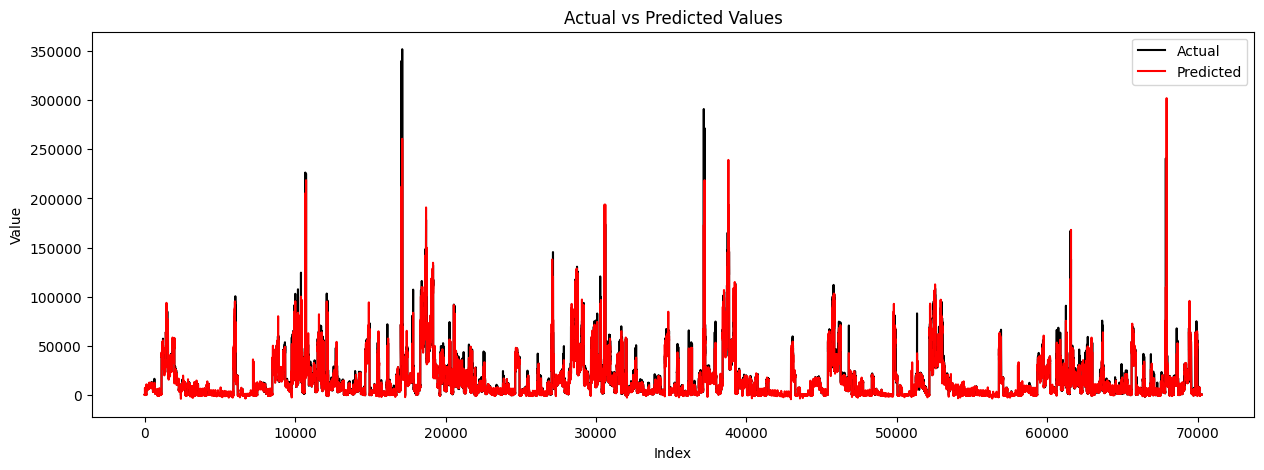

In [56]:
import matplotlib.pyplot as plt

# Get predictions
y_pred = final_pipe.predict(X_val)

# Create a DataFrame for plotting
df_plot = pd.DataFrame({
    'Actual': y_val,
    'Predicted': y_pred
})

# Plot both lines
plt.figure(figsize=(15,5))
plt.plot(df_plot['Actual'].values, label='Actual', color='black')
plt.plot(df_plot['Predicted'].values, label='Predicted', color='red')
plt.title('Actual vs Predicted Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()